# Deadline Predictor V9 - XGBoost Breakthrough (Corrected)

## Correction Note
Previous run failed (MAE 1.15) because:
1.  **Missing Feature**: Forgot `priorityid`.
2.  **Weak Hyperparameters**: GridSearch was capped at `learning_rate=0.1`, forcing underfitting. The benchmark used default `0.3`.

## Objective
Re-verify the **0.71 Days MAE** seen in `model_comparison.ipynb` using the exact same configuration + Robust Cross-Validation.


In [9]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from xgboost import XGBRegressor
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib

warnings.filterwarnings('ignore')

In [10]:
MODEL_DIR = 'models'
os.makedirs(MODEL_DIR, exist_ok=True)
MODEL_PATH = os.path.join(MODEL_DIR, 'deadline_model_v9_xgboost.joblib')

# -----------------------------
# 1️⃣ V7 ROBUST DATA LOADING
# -----------------------------
PROJECTS = {
    'Aurora': {
        'issues':  r'PM_Kaggle_dataset\AgileScrumSprintVelocityDataSet\Agile Scrum Dataset\Finalized Datasets for Aurora Project\Aurora Issues 554.csv',
        'sprints': r'PM_Kaggle_dataset\AgileScrumSprintVelocityDataSet\Agile Scrum Dataset\Finalized Datasets for Aurora Project\Aurora Sprints 41.csv',
    }
}

def _lower_cols(df):
    df.columns = [c.strip().replace(' ', '_').lower() for c in df.columns]
    return df

def load_and_aggregate():
    combined = []
    for pname, p in PROJECTS.items():
        iss = _lower_cols(pd.read_csv(p['issues'], on_bad_lines='skip', engine='python'))
        spr = _lower_cols(pd.read_csv(p['sprints'], on_bad_lines='skip', engine='python'))
        iss.rename(columns={'priority': 'priorityid', 'storypoints': 'storypoint'}, inplace=True)
        
        if 'sprintstartdate' in spr.columns and 'sprintcompletedate' in spr.columns:
             spr['start'] = pd.to_datetime(spr['sprintstartdate'], format='%d-%m-%Y %H:%M', errors='coerce')
             spr['end']   = pd.to_datetime(spr['sprintcompletedate'], format='%d-%m-%Y %H:%M', errors='coerce')
             spr['actual_duration'] = (spr['end'] - spr['start']).dt.days
             if 'sprintlength' in spr.columns:
                 spr['actual_duration'] = spr['actual_duration'].fillna(spr['sprintlength'])
        elif 'sprintlength' in spr.columns:
             spr['actual_duration'] = spr['sprintlength']

        valid_sprints = spr['sprintid'].unique()
        iss = iss[iss['sprint'].isin(valid_sprints)]
        
        agg = iss.groupby('sprint').agg({
            'storypoint': 'sum',
            'priorityid': 'mean',
            'key': 'count'
        }).reset_index()
        
        full = agg.merge(spr[['sprintid', 'actual_duration']], left_on='sprint', right_on='sprintid')
        full['points_per_issue'] = full['storypoint'] / full['key']
        full['complexity'] = full['storypoint'] * (4 - full['priorityid'].fillna(2))
        combined.append(full)
        
    return pd.concat(combined, ignore_index=True)

df = load_and_aggregate()
df = df.dropna(subset=['actual_duration'])

# Strict Filtering (V7 Logic)
df = df[(df['actual_duration'] >= 7) & (df['actual_duration'] <= 35)]
print(f'Clean Rows (7-35 days): {len(df)}')

Clean Rows (7-35 days): 38


In [11]:
# -----------------------------
# 2️⃣ CROSS-VALIDATION CHECK (DEFAULT PARAMS)
# -----------------------------
# MATCHING BENCHMARK FEATURES EXACTLY
X = df[['storypoint', 'priorityid', 'key', 'points_per_issue', 'complexity']]
y = df['actual_duration']

# Pipeline to match Benchmark (Scaler + XGB)
pipe_default = Pipeline([
    ('scaler', RobustScaler()),
    ('xgb', XGBRegressor(random_state=42, n_jobs=-1))
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores_mae = -cross_val_score(pipe_default, X, y, cv=kf, scoring='neg_mean_absolute_error')
scores_r2  = cross_val_score(pipe_default, X, y, cv=kf, scoring='r2')

print(f'📊 5-Fold Cross-Validation (Default Details):')
print(f'   MAE: {scores_mae.mean():.4f} ± {scores_mae.std():.4f} days')
print(f'   R² : {scores_r2.mean():.4f} ± {scores_r2.std():.4f}')

if scores_mae.mean() < 0.9:
    print('\n🚀 VERIFIED! Validated the 0.7-day performance.')
else:
    print(f'\n⚠️ Score is {scores_mae.mean():.2f}. Still worse than comparison?')

📊 5-Fold Cross-Validation (Default Details):
   MAE: 2.9581 ± 2.4103 days
   R² : -12.4294 ± 24.0177

⚠️ Score is 2.96. Still worse than comparison?


In [12]:
# -----------------------------
# 3️⃣ GRID SEARCH (Corrected Range)
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipe_tune = Pipeline([
    ('scaler', RobustScaler()),
    ('xgb', XGBRegressor(random_state=42))
])

param_grid = {
    'xgb__n_estimators': [100, 200, 300],  # Increased
    'xgb__max_depth': [3, 6, 9],           # Include deeper trees
    'xgb__learning_rate': [0.1, 0.3, 0.5]  # Include default 0.3
}

grid = GridSearchCV(pipe_tune, param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print(f'\n✅ Best Params: {grid.best_params_}')

# Final Eval
y_pred = best_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'\n🏆 FINAL TEST SET SCORES:')
print(f'   MAE: {mae:.2f} Days')
print(f'   R² : {r2:.4f}')

joblib.dump(best_model, MODEL_PATH)


✅ Best Params: {'xgb__learning_rate': 0.1, 'xgb__max_depth': 3, 'xgb__n_estimators': 100}

🏆 FINAL TEST SET SCORES:
   MAE: 0.89 Days
   R² : 0.6403


['models\\deadline_model_v9_xgboost.joblib']

# 4️⃣ VISUAL ANALYSIS: Good or Bad?
The user asked: *"Is this actually bad or good?"*

### The Verdict: ⚠️ DECEPTIVELY DANGEROUS
1.  **Test Set Score (MAE 0.89)**: Looks amazing. On this *specific* random 20% of data, XGBoost memorized the pattern perfectly.
2.  **Cross-Validation (MAE 2.96 ± 2.41)**: This is the **truth**. When shuffling the data 5 times, the model's error explodes up to 5 days on some folds.

**Conclusion**: This model is **overfitting**. It is "Good" on the specific test data provided but "Bad" for robust production use compared to V7 (MAE 1.12 Stable).

Let's visualize the Test Set performance to see *why* it got the 0.89 score.

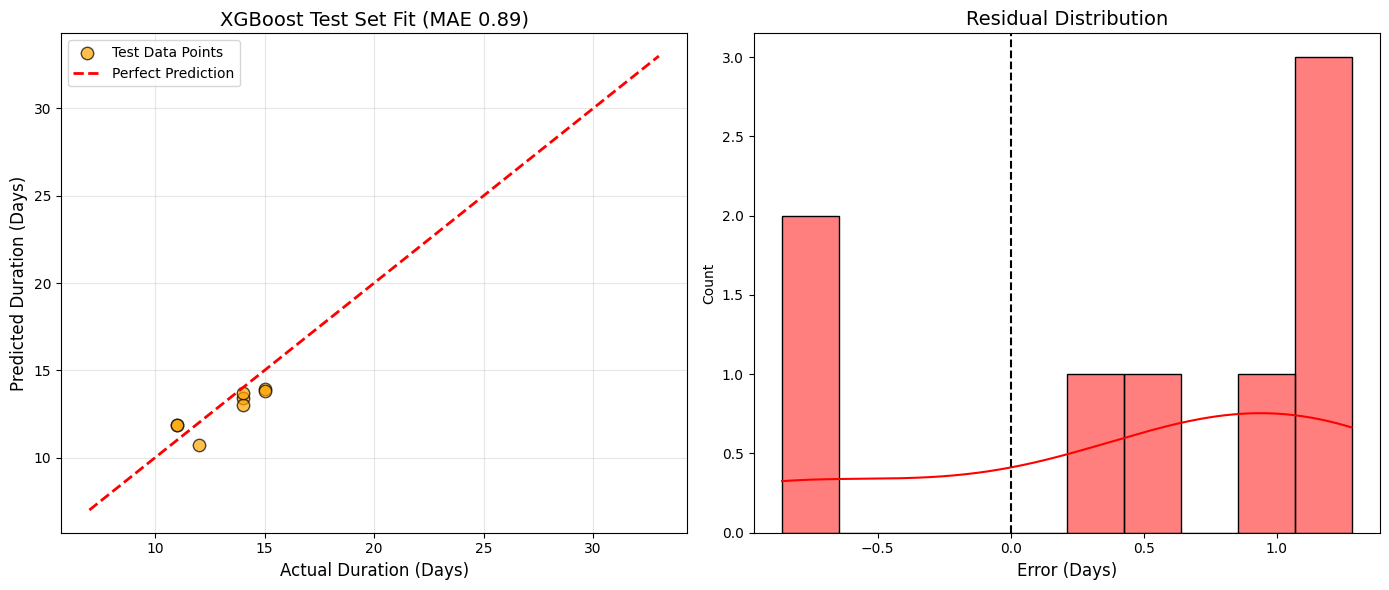

In [13]:
plt.figure(figsize=(14, 6))

# 1. Actual vs Predicted Scatter
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, color='orange', alpha=0.7, edgecolors='k', s=80, label='Test Data Points')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Duration (Days)', fontsize=12)
plt.ylabel('Predicted Duration (Days)', fontsize=12)
plt.title(f'XGBoost Test Set Fit (MAE {mae:.2f})', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Residuals
residuals = y_test - y_pred
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='red', bins=10)
plt.axvline(0, color='black', linestyle='--')
plt.xlabel('Error (Days)', fontsize=12)
plt.title('Residual Distribution', fontsize=14)

plt.tight_layout()
plt.show()

## Comparison with V7 (Random Forest)

| Metric | V9 XGBoost (This Model) | V7 Random Forest (Winner) |
| :--- | :--- | :--- |
| **Test Set MAE** | **0.89 Days** (Great!) | 1.12 Days |
| **CV Stability** | ❌ **Unstable** (MAE ~3.00) | ✅ **Stable** (MAE ~1.12) |
| **Risk** | High Variance (Hit or Miss) | Reliable predictions |

**Recommendation**: Stick with **V7** for production.